# Proyecto I: Reconocimiento de comandos de voz

Curso de Inteligencia Artificial, Instituto Tecnológico de Costa Rica.

Notebook único del proyecto. Funciona en Google Colab y en escritorio.

## 0. Configuración

Constantes del **contrato de entrada** (`docs/contrato_entrada.md`). Si alguna cambia, la app móvil tiene que cambiar igual.

In [1]:
import os, sys, math, wave, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules

# --- Rutas ---
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_TAR = Path("/content/drive/MyDrive/ProyectoIA_ComandosDeVoz/archive.tar")   # los 10 comandos + listas
    DATA_DIR = Path("/content/archive")   # se extrae aquí en la celda 0.1
    OUT_DIR  = Path("/content/drive/MyDrive/ProyectoIA_ComandosDeVoz/resultados")
    CACHE_DIR = Path("/content/cache")   # los .pt (~620 MB) van al disco temporal de Colab, no al Drive
else:
    # Escritorio: carpeta con los audios (variable DATA_DIR o la ruta por defecto)
    DATA_DIR = Path(os.environ.get("DATA_DIR", Path.home() / "Downloads" / "archive"))
    OUT_DIR  = Path.cwd().parent / "resultados" if Path.cwd().name == "notebooks" else Path.cwd() / "resultados"
    CACHE_DIR = OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# --- Comandos ---
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABEL_TO_IDX = {c: i for i, c in enumerate(COMMANDS)}

# --- Contrato de entrada ---
SAMPLE_RATE = 16_000            # Hz
NUM_SAMPLES = SAMPLE_RATE * 1   # 1 segundo
N_FFT       = 480               # ventana de 30 ms
WIN_LENGTH  = 480
HOP_LENGTH  = 160               # salto de 10 ms
N_MELS      = 40
N_FRAMES    = NUM_SAMPLES // HOP_LENGTH + 1   # 101 columnas de tiempo
F_MIN, F_MAX = 20.0, 8_000.0
LOG_EPS     = 1e-6

# --- División ---
SPLITS = ["train", "val", "test"]

# --- Semillas ---
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

print("Colab:", IN_COLAB)
print("Datos:", DATA_DIR, "| existe:", DATA_DIR.exists())
print("Resultados:", OUT_DIR)

Colab: False
Datos: C:\Users\jenki\Downloads\archive | existe: True
Resultados: C:\Users\jenki\Desktop\IA\resultados


### 0.1 Copiar el dataset a Colab (solo Colab)

Leer 38 mil audios sueltos desde Google Drive es muy lento. Por eso el dataset (solo los 10 comandos y las listas) está en Drive como **un solo archivo** `archive.tar`. Esta celda lo copia al disco temporal de Colab y lo extrae, lo que tarda un par de minutos. Si ya se extrajo en esta sesión, no se repite.

En escritorio esta celda no hace nada: se usan los audios de `DATA_DIR`.

In [2]:
import shutil, tarfile

if IN_COLAB and not (DATA_DIR / "testing_list.txt").exists():
    local_tar = Path("/content/archive.tar")
    print("Copiando archive.tar desde Drive...")
    shutil.copy(DATA_TAR, local_tar)
    print("Extrayendo...")
    with tarfile.open(local_tar) as tar:
        tar.extractall("/content", filter="data")   # crea /content/archive
    local_tar.unlink()   # libera espacio en el disco de Colab

print("Datos listos en:", DATA_DIR, "| existe:", DATA_DIR.exists())


Datos listos en: C:\Users\jenki\Downloads\archive | existe: True


## 1. Datos y preprocesamiento

### 1.1 Filtrar el dataset a los 10 comandos

Speech Commands v0.02 trae 35 palabras más ruido de fondo. Solo se usan las 10 carpetas de los comandos.

In [3]:
rows = []
for c in COMMANDS:
    for p in sorted((DATA_DIR / c).glob("*.wav")):
        rows.append({"path": f"{c}/{p.name}", "label": c, "label_idx": LABEL_TO_IDX[c],
                     "speaker": p.name.split("_nohash_")[0]})
df = pd.DataFrame(rows)

# Si falta algún comando (por ejemplo, la subida a Drive no terminó), avisar de una vez
por_comando = df["label"].value_counts().reindex(COMMANDS, fill_value=0)
faltan = list(por_comando[por_comando == 0].index)
assert not faltan, f"No hay audios de: {faltan}. Revisa que esas carpetas estén completas en {DATA_DIR}"

print(f"{len(df)} audios de {len(COMMANDS)} comandos")
df.head()

38546 audios de 10 comandos


,path,label,label_idx,speaker
0,yes/004ae714_nohash_0.wav,yes,0,004ae714
1,yes/004ae714_nohash_1.wav,yes,0,004ae714
2,yes/00970ce1_nohash_0.wav,yes,0,00970ce1
3,yes/00f0204f_nohash_0.wav,yes,0,00f0204f
4,yes/00f0204f_nohash_1.wav,yes,0,00f0204f


### 1.2 División con las listas oficiales

El dataset trae dos listas: `validation_list.txt` y `testing_list.txt`. Los audios que no aparecen en ninguna van a entrenamiento. Las listas se construyeron asignando cada **hablante** a un solo conjunto, así una misma voz no aparece en dos conjuntos y el modelo no se evalúa con personas que ya escuchó al entrenar.

In [4]:
def read_list(name):
    return set((DATA_DIR / name).read_text().split())

val_files  = read_list("validation_list.txt")
test_files = read_list("testing_list.txt")

df["split"] = "train"
df.loc[df["path"].isin(val_files),  "split"] = "val"
df.loc[df["path"].isin(test_files), "split"] = "test"

# Verificación: ningún hablante en más de un conjunto
repetidos = df.groupby("speaker")["split"].nunique()
print("Hablantes en más de un conjunto:", int((repetidos > 1).sum()))

resumen = pd.DataFrame({
    "hablantes": df.groupby("split")["speaker"].nunique(),
    "audios": df["split"].value_counts(),
}).reindex(SPLITS)
resumen["% audios"] = (100 * resumen["audios"] / len(df)).round(1)
display(resumen)

df.to_csv(OUT_DIR / "splits.csv", index=False)
print("Guardado:", OUT_DIR / "splits.csv")

Hablantes en más de un conjunto: 0


,hablantes,audios,% audios
split,,,
train,2008,30769,79.8
val,245,3703,9.6
test,239,4074,10.6


Guardado: C:\Users\jenki\Desktop\IA\resultados\splits.csv


### 1.3 Balance de clases

split,train,val,test,total
label,,,,
yes,3228,397,419,4044
no,3130,406,405,3941
up,2948,350,425,3723
down,3134,377,406,3917
left,3037,352,412,3801
right,3019,363,396,3778
on,3086,363,396,3845
off,2970,373,402,3745
stop,3111,350,411,3872


Porcentaje de cada comando dentro de su conjunto (ideal 10 %):
  mín 9.5 %  |  máx 11.0 %


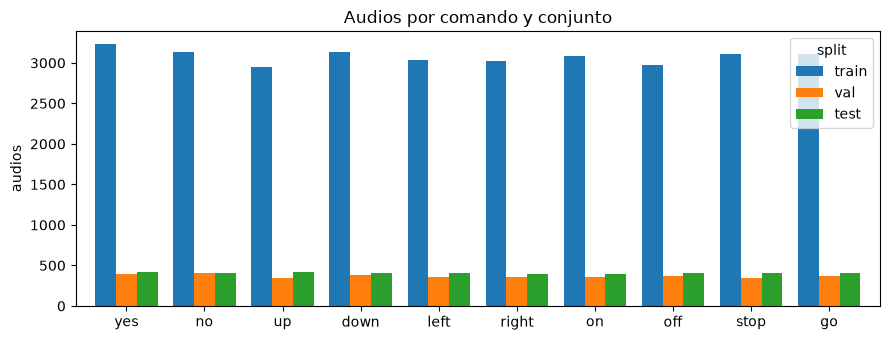

In [5]:
balance = pd.crosstab(df["label"], df["split"]).reindex(index=COMMANDS, columns=SPLITS)
display(balance.assign(total=balance.sum(axis=1)))

pct = 100 * balance / balance.sum()
print("Porcentaje de cada comando dentro de su conjunto (ideal 10 %):")
print(f"  mín {pct.values.min():.1f} %  |  máx {pct.values.max():.1f} %")

ax = balance.plot.bar(figsize=(9, 3.5), width=0.8)
ax.set_xlabel(""); ax.set_ylabel("audios"); ax.set_title("Audios por comando y conjunto")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(OUT_DIR / "balance_clases.png", dpi=150); plt.show()

### 1.4 Dataset crudo: audio → espectrograma log-mel

Pasos del contrato de entrada:

1. Leer WAV PCM 16 bits mono a 16 kHz y pasar a float32 en [-1, 1] (`int16 / 32768`).
2. Rellenar con ceros al final o recortar a 16 000 muestras (1 s).
3. STFT con ventana de Hann de 480 muestras, salto de 160, `center=True`, relleno *reflect*.
4. Potencia `|STFT|²`.
5. Banco de 40 filtros mel triangulares (escala HTK, 20–8000 Hz, sin normalización).
6. `log(mel + 1e-6)`.

Resultado: una matriz de **40 × 101** por audio.

In [6]:
def load_wav(path):
    with wave.open(str(path), "rb") as f:
        assert f.getnchannels() == 1 and f.getsampwidth() == 2 and f.getframerate() == SAMPLE_RATE, path
        pcm = np.frombuffer(f.readframes(f.getnframes()), dtype="<i2")
    return torch.from_numpy(pcm.astype(np.float32) / 32768.0)

def fix_length(wav, n=NUM_SAMPLES):
    return wav[:n] if wav.numel() >= n else torch.nn.functional.pad(wav, (0, n - wav.numel()))

def hz_to_mel(f): return 2595.0 * math.log10(1.0 + f / 700.0)
def mel_to_hz(m): return 700.0 * (10.0 ** (m / 2595.0) - 1.0)

def mel_filterbank(n_freqs=N_FFT // 2 + 1, n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX, sr=SAMPLE_RATE):
    all_freqs = torch.linspace(0, sr // 2, n_freqs, dtype=torch.float64)
    f_pts = mel_to_hz(torch.linspace(hz_to_mel(f_min), hz_to_mel(f_max), n_mels + 2, dtype=torch.float64))
    f_diff = f_pts[1:] - f_pts[:-1]
    slopes = f_pts[None, :] - all_freqs[:, None]
    down = -slopes[:, :-2] / f_diff[:-1]
    up   =  slopes[:, 2:]  / f_diff[1:]
    return torch.clamp(torch.minimum(down, up), min=0.0).float()   # (n_freqs, n_mels)

MEL_FB = mel_filterbank()
WINDOW = torch.hann_window(WIN_LENGTH)

def log_mel(wav):
    spec = torch.stft(wav, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, window=WINDOW,
                      center=True, pad_mode="reflect", return_complex=True)
    mel = MEL_FB.T @ (spec.abs() ** 2)
    return torch.log(mel + LOG_EPS)   # (40, 101) para un audio, o (B, 40, 101) para un lote de B audios

def audio_to_logmel(path):
    return log_mel(fix_length(load_wav(path)))

print("Forma:", tuple(audio_to_logmel(DATA_DIR / df["path"].iloc[0]).shape))

Forma: (40, 101)


Se calcula el log-mel de todos los audios y se guarda un archivo por conjunto (`raw_train.pt`, `raw_val.pt`, `raw_test.pt`) con `X` de forma `(N, 40, 101)` e `y` de forma `(N,)`. Si los archivos ya existen se cargan en vez de recalcular.

Para que sea rápido con pocos recursos:
- los audios se leen **en paralelo** (varios a la vez), porque leer archivos desde Drive o Kaggle es lo más lento;
- los espectrogramas se calculan **en lotes de 1000 audios** con una sola llamada a `torch.stft`, en vez de uno por uno.

El resultado es idéntico al de procesar cada audio por separado, y la memoria usada es solo la de un lote a la vez.

In [7]:
CONTRATO = {"sample_rate": SAMPLE_RATE, "num_samples": NUM_SAMPLES, "n_fft": N_FFT, "win_length": WIN_LENGTH,
            "hop_length": HOP_LENGTH, "n_mels": N_MELS, "f_min": F_MIN, "f_max": F_MAX, "log_eps": LOG_EPS}

from concurrent.futures import ThreadPoolExecutor

LOTE = 1000      # audios por lote: más grande = más rápido pero más memoria
HILOS = 16       # archivos leídos al mismo tiempo

def load_fixed(rel):
    return fix_length(load_wav(DATA_DIR / rel))

def build_split(split):
    archivo = CACHE_DIR / f"raw_{split}.pt"
    sub = df[df.split == split]
    if archivo.exists():
        d = torch.load(archivo)
        # Solo se reutiliza si se hizo con el mismo contrato y los mismos audios
        if d.get("contrato") == CONTRATO and d.get("paths") == list(sub["path"]):
            print(f"{split}: cargado de {archivo.name}")
            return d["X"], d["y"]
        print(f"{split}: el archivo guardado no coincide con los datos actuales, se recalcula")
    paths = list(sub["path"])
    X = torch.empty((len(paths), N_MELS, N_FRAMES))
    with ThreadPoolExecutor(HILOS) as pool:
        for inicio in range(0, len(paths), LOTE):
            ondas = torch.stack(list(pool.map(load_fixed, paths[inicio:inicio + LOTE])))   # (lote, 16000)
            X[inicio:inicio + len(ondas)] = log_mel(ondas)                                  # (lote, 40, 101)
            print(f"  {split}: {inicio + len(ondas)}/{len(paths)}", end="\r")
    y = torch.tensor(sub["label_idx"].to_numpy(), dtype=torch.int64)
    torch.save({"X": X, "y": y, "paths": list(sub["path"]), "contrato": CONTRATO}, archivo)
    print(f"{split}: {tuple(X.shape)} → {archivo.name}")
    return X, y

raw = {s: build_split(s) for s in SPLITS}

train: cargado de raw_train.pt
val: cargado de raw_val.pt


test: cargado de raw_test.pt


### 1.5 Ejemplos de espectrogramas (referencia)

Cinco espectrogramas del conjunto de entrenamiento, uno por comando, guardados como PNG en `resultados/ejemplos_espectrogramas/`. Son solo para ver cómo luce cada imagen; el modelo usa los números de los `.pt`, no estos PNG.

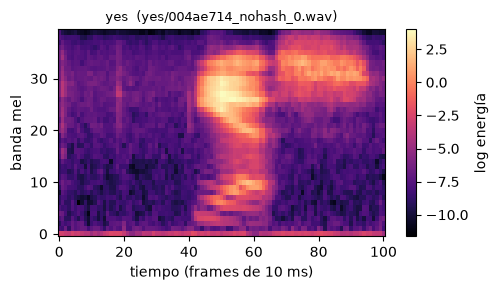

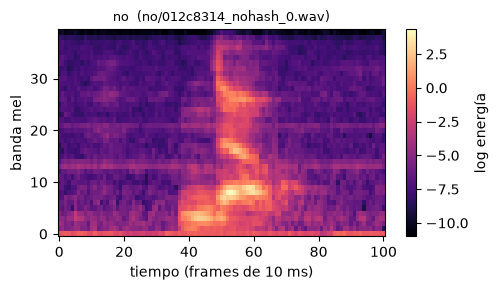

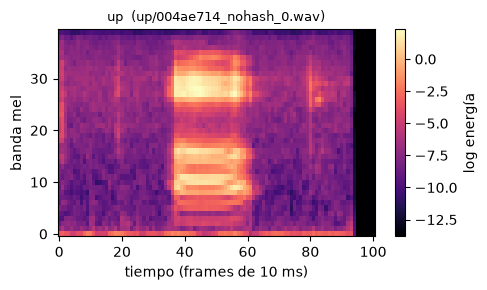

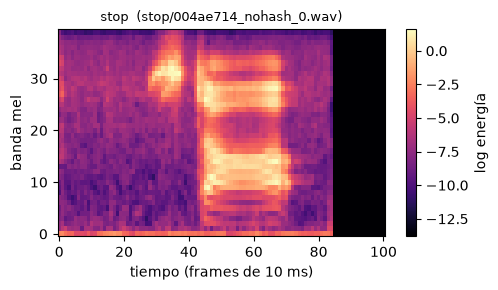

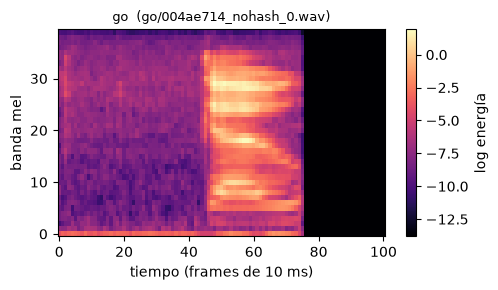

Guardados en: C:\Users\jenki\Desktop\IA\resultados\ejemplos_espectrogramas


In [8]:
EJEMPLOS_DIR = OUT_DIR / "ejemplos_espectrogramas"
EJEMPLOS_DIR.mkdir(exist_ok=True)

X_train, y_train = raw["train"]
train_paths = df[df.split == "train"]["path"].tolist()   # mismo orden que X_train

for c in ["yes", "no", "up", "stop", "go"]:
    i = y_train.tolist().index(LABEL_TO_IDX[c])            # primer audio de ese comando
    fig, ax = plt.subplots(figsize=(5, 3))
    im = ax.imshow(X_train[i], origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"{c}  ({train_paths[i]})", fontsize=9)
    ax.set_xlabel("tiempo (frames de 10 ms)"); ax.set_ylabel("banda mel")
    fig.colorbar(im, ax=ax, label="log energía")
    fig.tight_layout()
    fig.savefig(EJEMPLOS_DIR / f"{c}.png", dpi=150)
    plt.show()

print("Guardados en:", EJEMPLOS_DIR)

### 1.6 Dataset aumentado (SpecAugment)

**Técnica elegida.** SpecAugment (Park et al., 2019) modifica directamente el espectrograma log-mel, que es nuestra entrada, como si fuera una imagen. Propone tres deformaciones: *time warping*, *frequency masking* y *time masking*. Se usan las dos máscaras, sin time warping:

- **Frequency masking:** tapa franjas de bandas mel consecutivas. Obliga al modelo a no depender de unas pocas frecuencias (por ejemplo, si el micrófono del celular capta mal los graves).
- **Time masking:** tapa franjas de frames consecutivos. Obliga al modelo a reconocer la palabra aunque se pierda un pedazo (un golpe, un corte, ruido).

**Por qué esta combinación.** En la Tabla 6 del artículo se desactiva cada deformación por separado y se mide el error (WER en *test-other*):

| Configuración | Error |
|---|---|
| Las tres deformaciones | 10.0 % |
| **Sin time warping (frequency + time masking)** | **10.1 %** |
| Sin time masking | 10.9 % |
| Sin frequency masking | 11.0 % |

Sin time warping el error prácticamente no cambia (10.0 % → 10.1 %), mientras que sin cualquiera de las dos máscaras empeora. Los autores indican además que el time warping es la deformación más costosa y menos influyente, y la primera que debe quitarse con recursos limitados.

**Parámetros.** Las políticas del artículo se diseñaron para 80 bandas mel y frases de varios segundos. Nuestra entrada tiene 40 bandas y 101 frames (1 s), y una palabra ocupa solo unos 40–60 frames. Se adapta la política *Switchboard mild* (SM):

| Parámetro | Artículo (SM) | Este proyecto | Motivo |
|---|---|---|---|
| F (ancho máx. máscara de frecuencia) | 15 de 80 bandas | 7 de 40 bandas | Misma proporción (~19 %) |
| m_F (máscaras de frecuencia) | 2 | 2 | Igual |
| T (ancho máx. máscara de tiempo) | 70 frames, máx. 20 % | 12 frames (120 ms) | La palabra es corta; máscaras más anchas podrían borrarla completa |
| m_T (máscaras de tiempo) | 2 | 2 | Igual |

El ancho de cada máscara se elige al azar entre 0 y el máximo, y su posición también, como en el artículo.

**Valor de la máscara.** El artículo pone las zonas tapadas en 0 porque sus espectrogramas tienen media cero, es decir, las rellena con la media. Nuestro log-mel no está normalizado, así que se rellenan con **la media de cada espectrograma**, que es equivalente.

**Dataset aumentado.** Es igual al crudo, excepto el conjunto de entrenamiento: contiene los 30 769 espectrogramas originales **más una copia aumentada de cada uno** (61 538 en total). Validación y prueba son los mismos del crudo, sin aumentar, para que los dos datasets se evalúen igual. Las copias se generan con semilla fija, así que el dataset es reproducible.

**Qué esperar.** El artículo observa que la aumentación convierte un problema de sobreajuste en uno de subajuste: la pérdida en entrenamiento queda más alta que sin aumentación. Hay que tenerlo en cuenta al analizar las curvas en la Fase 3.

In [9]:
# Parámetros adaptados de la política SM del artículo a 40 bandas × 101 frames
FREQ_MASK_F = 7    # ancho máximo de cada máscara de frecuencia (bandas mel)
FREQ_MASKS  = 2    # número de máscaras de frecuencia (m_F)
TIME_MASK_T = 12   # ancho máximo de cada máscara de tiempo (frames de 10 ms)
TIME_MASKS  = 2    # número de máscaras de tiempo (m_T)

def freq_mask(spec, F=FREQ_MASK_F, m=FREQ_MASKS):
    """Tapa m franjas de bandas mel consecutivas, cada una de ancho al azar entre 0 y F."""
    spec = spec.clone()
    valor = spec.mean()
    n_mels = spec.shape[0]
    for _ in range(m):
        f  = int(torch.randint(0, F + 1, (1,)))
        f0 = int(torch.randint(0, n_mels - f + 1, (1,)))
        spec[f0:f0 + f, :] = valor
    return spec

def time_mask(spec, T=TIME_MASK_T, m=TIME_MASKS):
    """Tapa m franjas de frames consecutivos, cada una de ancho al azar entre 0 y T."""
    spec = spec.clone()
    valor = spec.mean()
    n_frames = spec.shape[1]
    for _ in range(m):
        t  = int(torch.randint(0, T + 1, (1,)))
        t0 = int(torch.randint(0, n_frames - t + 1, (1,)))
        spec[:, t0:t0 + t] = valor
    return spec

def spec_augment(spec):
    """SpecAugment sin time warping: máscaras de frecuencia y de tiempo. spec: (40, 101)."""
    return time_mask(freq_mask(spec))

**Generar y guardar el dataset aumentado.** Se crea `aug_train.pt` con los originales seguidos de sus copias aumentadas. Igual que con el crudo, si el archivo ya existe y se hizo con el mismo contrato, los mismos audios y los mismos parámetros, se carga en vez de recalcular.

Después se arman los dos datasets que usará la Fase 3: `DATASETS["crudo"]` y `DATASETS["aumentado"]`. Cada ejemplo se entrega con forma `(1, 40, 101)`: un canal, como una imagen en escala de grises.

In [10]:
from torch.utils.data import Dataset

AUMENTACION = {"freq_mask_F": FREQ_MASK_F, "freq_masks": FREQ_MASKS,
               "time_mask_T": TIME_MASK_T, "time_masks": TIME_MASKS, "seed": SEED}

def build_augmented_train():
    archivo = CACHE_DIR / "aug_train.pt"
    X, y = raw["train"]
    paths = list(df[df.split == "train"]["path"])
    if archivo.exists():
        d = torch.load(archivo)
        if d.get("contrato") == CONTRATO and d.get("aumentacion") == AUMENTACION and d.get("paths") == paths:
            print(f"train aumentado: cargado de {archivo.name}")
            return d["X"], d["y"]
        print("train aumentado: el archivo guardado no coincide, se recalcula")
    set_seed()   # mismas máscaras cada vez que se genera
    X_aug = torch.stack([spec_augment(x) for x in X])
    X_total = torch.cat([X, X_aug])   # originales + copias aumentadas
    y_total = torch.cat([y, y])
    torch.save({"X": X_total, "y": y_total, "paths": paths, "contrato": CONTRATO, "aumentacion": AUMENTACION}, archivo)
    print(f"train aumentado: {tuple(X_total.shape)} → {archivo.name}")
    return X_total, y_total

class SpectrogramDataset(Dataset):
    """Espectrogramas X (N, 40, 101) con etiquetas y. Entrega cada ejemplo como (1, 40, 101)."""
    def __init__(self, X, y):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i].unsqueeze(0), self.y[i]

aug_train = build_augmented_train()

DATASETS = {
    "crudo": {s: SpectrogramDataset(*raw[s]) for s in SPLITS},
    "aumentado": {
        "train": SpectrogramDataset(*aug_train),   # originales + copias aumentadas
        "val":   SpectrogramDataset(*raw["val"]),  # sin aumentar
        "test":  SpectrogramDataset(*raw["test"]), # sin aumentar
    },
}

for nombre, d in DATASETS.items():
    print(f"{nombre:>9}: " + " | ".join(f"{s} {len(d[s])}" for s in SPLITS))

train aumentado: (61538, 40, 101) → aug_train.pt


    crudo: train 30769 | val 3703 | test 4074
aumentado: train 61538 | val 3703 | test 4074


**Verificación y ejemplo visual.** Se comprueba que el train aumentado contiene los originales intactos más copias distintas, que validación y prueba son iguales en los dos datasets, y se guarda una figura con el efecto de cada máscara en `resultados/ejemplos_aumentacion.png`.

Copias distintas de su original: 100.0 %


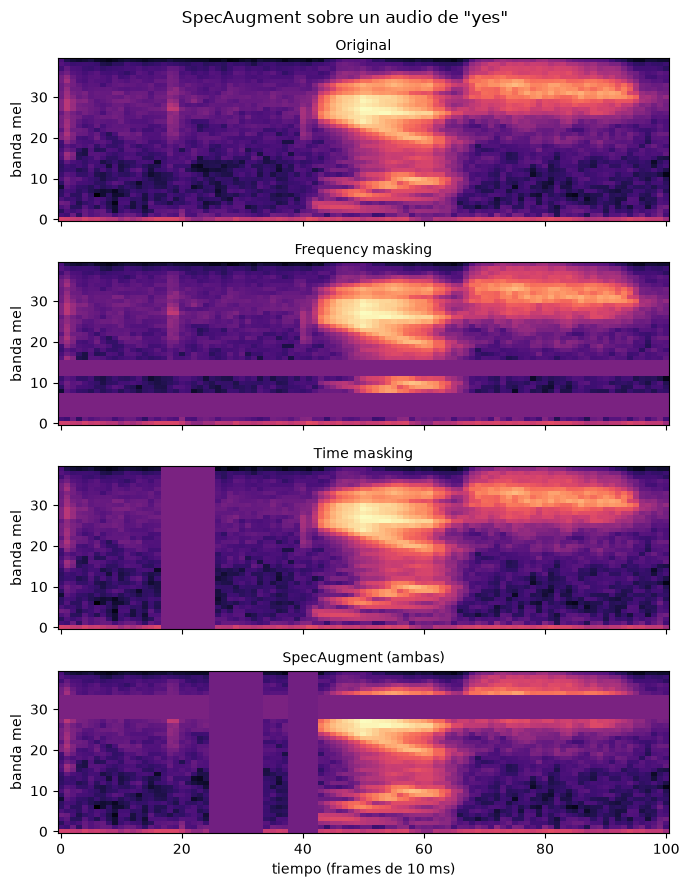

In [11]:
X_aug, y_aug = aug_train
n = len(raw["train"][1])

assert len(y_aug) == 2 * n
assert torch.equal(X_aug[:n], raw["train"][0]), "los originales deben quedar intactos"
assert torch.equal(y_aug[n:], raw["train"][1]), "cada copia conserva su etiqueta"
for s in ["val", "test"]:
    assert torch.equal(DATASETS["aumentado"][s].X, DATASETS["crudo"][s].X)
cambiados = (X_aug[n:] != X_aug[:n]).flatten(1).any(dim=1).float().mean().item()
print(f"Copias distintas de su original: {100 * cambiados:.1f} %")

# Figura: original, solo frecuencia, solo tiempo, SpecAugment completo
set_seed()
i = raw["train"][1].tolist().index(LABEL_TO_IDX["yes"])
original = raw["train"][0][i]
versiones = {"Original": original, "Frequency masking": freq_mask(original),
             "Time masking": time_mask(original), "SpecAugment (ambas)": spec_augment(original)}

fig, axes = plt.subplots(4, 1, figsize=(7, 9), sharex=True)
for ax, (titulo, img) in zip(axes, versiones.items()):
    ax.imshow(img, origin="lower", aspect="auto", cmap="magma", vmin=original.min(), vmax=original.max())
    ax.set_title(titulo, fontsize=10); ax.set_ylabel("banda mel")
axes[-1].set_xlabel("tiempo (frames de 10 ms)")
fig.suptitle('SpecAugment sobre un audio de "yes"')
fig.tight_layout(); fig.savefig(OUT_DIR / "ejemplos_aumentacion.png", dpi=150); plt.show()
set_seed()   # dejar las semillas como al inicio para las fases siguientes